🔍 Loading data...


📊 Trainval: 29109, Test: 5137
⚙️ Using device: mps
✅ TensorFlow → CPU only
📦 Loading base models...
   Loading TF-IDF + SVM...

🚀 Generating OOF meta-features (5-fold CV)
📁 Fold 1/5


/var/folders/y0/33xgrsyx18j1bp7lv_zr_j600000gn/T/ipykernel_10893/2548186515.py:100: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  soup = BeautifulSoup(text, "html.parser")


📁 Fold 2/5
📁 Fold 3/5
📁 Fold 4/5
📁 Fold 5/5

✅ OOF meta-feature matrix shape: (29109, 40)

🔧 Scaling meta-features...


/var/folders/y0/33xgrsyx18j1bp7lv_zr_j600000gn/T/ipykernel_10893/2548186515.py:100: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  soup = BeautifulSoup(text, "html.parser")


✅ Test meta shape: (5137, 40)

🧠 TRAINING XGBOOST META-LEARNER (Weighted)
✅ XGBoost Final Test Accuracy: 0.7520 (75.20%)

🧠 TRAINING LOGISTIC REGRESSION META-LEARNER


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


✅ LR Final Test Accuracy: 0.7438 (74.38%)

📊 META-LEARNER COMPARISON
Meta-Learner    Default    Thresholded  Δ Tuning   Best      
----------------------------------------------------------------------
XGBoost         0.7500     0.7520       +0.0019    ★
Logistic Reg    0.7430     0.7438       +0.0008    
----------------------------------------------------------------------
🎯 Overall Best: XGBoost @ 0.7520

📈 FINAL REPORT (XGB Meta-Learner)
                precision    recall  f1-score   support

self-direction       0.79      0.78      0.78       859
   stimulation       0.74      0.76      0.75       401
      hedonism       0.83      0.83      0.83      1142
   achievement       0.63      0.57      0.60       298
         power       0.79      0.78      0.79       310
      security       0.84      0.82      0.83       404
    conformity       0.67      0.68      0.67       659
     tradition       0.78      0.78      0.78       298
   benevolence       0.70      0.71      0.70    

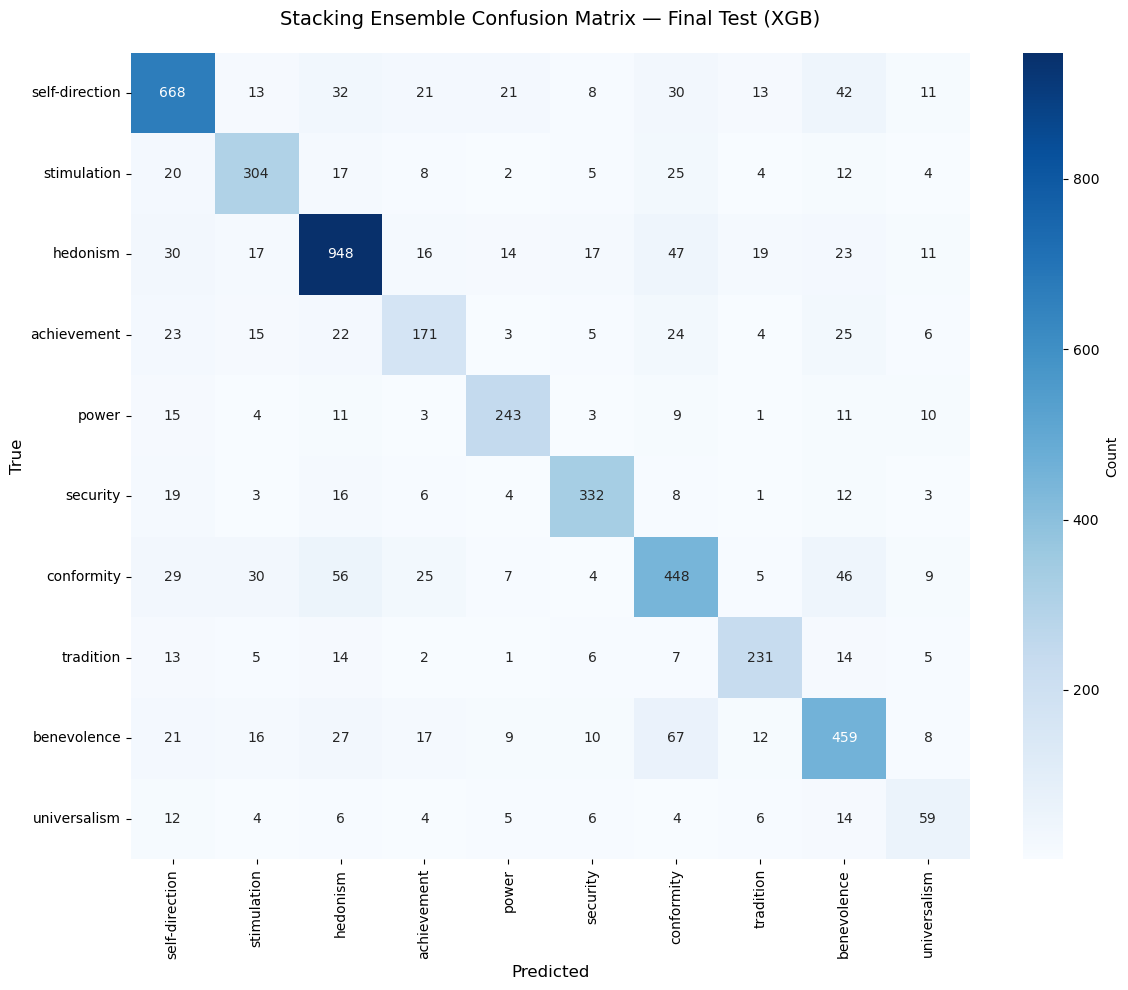


🔍 XGBoost Feature Importance (per base model)
  GRU      : 0.0001
  BERT     : 0.0880
  RoBERTa  : 0.0118
  TF-IDF SVM : 0.0001
✅ Importance plot saved: 'xgboost_meta_importance.png'


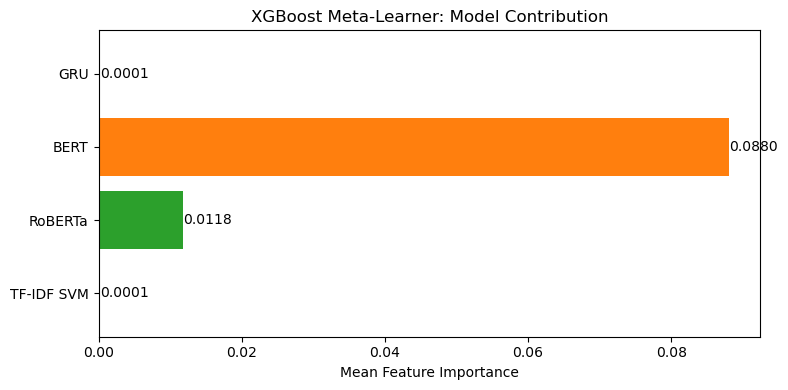


✅ Best meta-learner (XGB) saved: 'human_values_stacking_xgb_weighted.pkl'
✅ Scaler saved: 'meta_scaler.pkl'
✅ Optimal thresholds saved: 'optimal_thresholds_xgb.pkl'


In [3]:
# ==============================
# STACKING ENSEMBLE — XGBoost vs Logistic Regression Meta-Learners
# Base models: GRU, BERT, RoBERTa, TF-IDF+SVM
# Goal: ≥76% test accuracy
# ==============================
import os
import pandas as pd
import numpy as np
import re
import pickle
import gc
import torch
import joblib
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.corpus import stopwords, wordnet as wn
from collections import defaultdict
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression  # ← ADDED
from transformers import (
    RobertaTokenizerFast,
    RobertaForSequenceClassification,
    BertTokenizerFast,
    BertForSequenceClassification
)
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ⚠️ Fix missing import
from bs4 import BeautifulSoup  # ← CRITICAL: was missing in original

# === Download NLTK resources (quiet) ===
nltk.download('punkt', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('stopwords', quiet=True)

# === Stability settings (critical for Mac) ===
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

# === Reproducibility ===
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# === Class order ===
your_class_order = [
    'self-direction', 'stimulation', 'hedonism', 'achievement', 'power',
    'security', 'conformity', 'tradition', 'benevolence', 'universalism'
]
n_classes = len(your_class_order)
y_dict = {label: idx for idx, label in enumerate(your_class_order)}

# === Load data ===
print("🔍 Loading data...")
df = pd.read_excel('combineddataset.xls')
df['category'] = df['category'].str.strip().str.lower().map(y_dict)
df = df.dropna(subset=['category'])
df['category'] = df['category'].astype(int)

# === Train/Test split ===
idx_all = np.arange(len(df))
y_all = df['category'].values
trainval_idx, test_idx = train_test_split(
    idx_all, test_size=0.15, random_state=SEED, stratify=y_all
)

df_test = df.iloc[test_idx].reset_index(drop=True)
X_test_raw = df_test['Base_Reviews'].values
y_test_true = df_test['category'].values

X_trainval = df.iloc[trainval_idx]['Base_Reviews'].values
y_trainval = df['category'].values[trainval_idx]
print(f"📊 Trainval: {len(X_trainval)}, Test: {len(X_test_raw)}")

# === Preprocessing for RNNs (CNN/BiGRU) ===
tag_map = defaultdict(lambda: 'n')  # default to noun
tag_map['J'] = 'a'  # adjective
tag_map['V'] = 'v'  # verb
tag_map['R'] = 'r'  # adverb

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text_for_rnn(text):
    """Exact replica of training preprocessing."""
    if not isinstance(text, str):
        return ""
    
    try:
        soup = BeautifulSoup(text, "html.parser")
        text = soup.get_text()
    except Exception as e:
        text = str(text)
    
    # 2. URL removal
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # 3. Lowercase & symbol cleaning
    text = text.lower()
    text = re.sub(r'[/(){}\[\]\<\>\|@,;]', ' ', text)  # replace with space
    text = re.sub(r'[^a-z #+_]', '', text)             # keep only a-z, space, #, +, _
    
    # 4. Tokenize, stopword remove, POS-aware lemmatize
    tokens = word_tokenize(text)
    final_words = []
    for word, pos in pos_tag(tokens):
        if word not in stop_words and word.isalpha():
            pos_tag_simple = tag_map[pos[0]] if pos else 'n'
            lemma = lemmatizer.lemmatize(word, pos=pos_tag_simple)
            final_words.append(lemma)
    return ' '.join(final_words)

# === Preprocessing for TF-IDF SVM ===
tag_map_svm = defaultdict(lambda: wn.NOUN)
tag_map_svm['J'] = wn.ADJ
tag_map_svm['V'] = wn.VERB
tag_map_svm['R'] = wn.ADV

lemmatizer_svm = WordNetLemmatizer()

def preprocess_for_svm(text):
    """Preprocessing exactly as used in TF-IDF+SVM training."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    final_words = []
    for word, pos in pos_tag(tokens):
        if word not in stop_words and word.isalpha():
            pos_simple = tag_map_svm[pos[0]] if pos else wn.NOUN
            lemma = lemmatizer_svm.lemmatize(word, pos=pos_simple)
            final_words.append(lemma)
    return ' '.join(final_words)

# === Device ===
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"⚙️ Using device: {device}")

# Force TF CPU
import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')
print("✅ TensorFlow → CPU only")

# ==============================
# LOAD BASE MODELS
# ==============================
print("📦 Loading base models...")

# GRU
gru_model = load_model('./final_gru_10class_cv.h5')
with open('./final_gru_tokenizer_cv.pkl', 'rb') as f:
    gru_tokenizer = pickle.load(f)

# BERT
bert_model = BertForSequenceClassification.from_pretrained('./bert_best')
bert_tokenizer = BertTokenizerFast.from_pretrained('./bert_best')
bert_model.to(device); bert_model.eval()

# RoBERTa
roberta_model = RobertaForSequenceClassification.from_pretrained('./roberta_best')
roberta_tokenizer = RobertaTokenizerFast.from_pretrained('./roberta_best')
roberta_model.to(device); roberta_model.eval()

# TF-IDF + SVM
print("   Loading TF-IDF + SVM...")
svm_model = joblib.load('tfidf_svm_final.pkl')
tfidf_vec = joblib.load('tfidf_vectorizer_final.pkl')

# ==============================
# PREDICTION FUNCTIONS
# ==============================
def get_gru_proba(texts):
    cleaned = [clean_text_for_rnn(t) for t in texts]
    seqs = gru_tokenizer.texts_to_sequences(cleaned)
    padded = pad_sequences(seqs, maxlen=100, padding='post')
    return gru_model.predict(padded, verbose=0)

def get_bert_proba(texts, batch_size=8):
    all_probs = []
    for i in range(0, len(texts), batch_size):
        batch = [str(t) for t in texts[i:i+batch_size]]
        inputs = bert_tokenizer(
            batch, padding=True, truncation=True, max_length=128, return_tensors="pt"
        ).to(device)
        with torch.no_grad():
            logits = bert_model(**inputs).logits
            probs = torch.softmax(logits, dim=-1).cpu().numpy()
        all_probs.append(probs)
    return np.vstack(all_probs)

def get_roberta_proba(texts, batch_size=6):
    all_probs = []
    for i in range(0, len(texts), batch_size):
        batch = [str(t) for t in texts[i:i+batch_size]]
        inputs = roberta_tokenizer(
            batch, padding=True, truncation=True, max_length=128, return_tensors="pt"
        ).to(device)
        with torch.no_grad():
            logits = roberta_model(**inputs).logits
            probs = torch.softmax(logits, dim=-1).cpu().numpy()
        all_probs.append(probs)
    return np.vstack(all_probs)

def get_svm_proba(texts):
    cleaned = [preprocess_for_svm(t) for t in texts]
    X_t = tfidf_vec.transform(cleaned)
    return svm_model.predict_proba(X_t)

# ==============================
# GENERATE OOF META-FEATURES (5-FOLD)
# ==============================
print("\n" + "="*60)
print("🚀 Generating OOF meta-features (5-fold CV)")
print("="*60)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
meta_features = np.zeros((len(X_trainval), n_classes * 4))  # 4 models × 10 classes
y_meta = y_trainval.copy()

for fold, (train_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval), 1):
    print(f"📁 Fold {fold}/5")
    X_val = X_trainval[val_idx]
    
    p_gru = get_gru_proba(X_val)
    p_bert = get_bert_proba(X_val)
    p_roberta = get_roberta_proba(X_val)
    p_svm = get_svm_proba(X_val)
    
    fold_meta = np.hstack([p_gru, p_bert, p_roberta, p_svm])
    meta_features[val_idx] = fold_meta

    del p_gru, p_bert, p_roberta, p_svm
    gc.collect()
    if device.type == 'mps':
        torch.mps.empty_cache()

print(f"\n✅ OOF meta-feature matrix shape: {meta_features.shape}")

# ==============================
# PREPROCESSING
# ==============================
print("\n🔧 Scaling meta-features...")
scaler = StandardScaler()
meta_features_scaled = scaler.fit_transform(meta_features)

test_meta = np.hstack([
    get_gru_proba(X_test_raw),
    get_bert_proba(X_test_raw),
    get_roberta_proba(X_test_raw),
    get_svm_proba(X_test_raw)
])
test_meta_scaled = scaler.transform(test_meta)
print(f"✅ Test meta shape: {test_meta.shape}")

# ==============================
# Threshold Tuning Helper
# ==============================
def tune_thresholds(oof_proba, y_true, n_classes):
    """Grid search per-class thresholds to maximize accuracy."""
    best_thresh = np.full(n_classes, 0.5)
    best_score = accuracy_score(y_true, np.argmax(oof_proba, axis=1))
    
    # Coarse grid: 0.3 → 0.7 in steps of 0.02
    for cls in range(n_classes):
        for th in np.arange(0.3, 0.71, 0.02):
            temp_thresh = best_thresh.copy()
            temp_thresh[cls] = th
            
            preds = []
            for probs in oof_proba:
                adj_probs = np.where(probs >= temp_thresh, probs, 0.0)
                pred = np.argmax(adj_probs) if adj_probs.sum() > 0 else np.argmax(probs)
                preds.append(pred)
            
            score = accuracy_score(y_true, preds)
            if score > best_score:
                best_score = score
                best_thresh = temp_thresh.copy()
    return best_thresh, best_score

# ==============================
# META-LEARNER 1: XGBOOST (Weighted)
# ==============================
print("\n" + "="*60)
print("🧠 TRAINING XGBOOST META-LEARNER (Weighted)")
print("="*60)

sample_weights = compute_sample_weight('balanced', y_meta)

xgb_meta = XGBClassifier(
    n_estimators=120,
    max_depth=5,
    learning_rate=0.08,
    reg_alpha=1.0,
    reg_lambda=2.0,
    objective='multi:softprob',
    num_class=n_classes,
    random_state=SEED,
    tree_method='hist',
    n_jobs=1,
    verbosity=0
)
xgb_meta.fit(meta_features_scaled, y_meta, sample_weight=sample_weights)

y_pred_xgb_default = xgb_meta.predict(test_meta_scaled)
acc_xgb_default = accuracy_score(y_test_true, y_pred_xgb_default)
y_proba_xgb_oof = xgb_meta.predict_proba(meta_features_scaled)
y_proba_xgb_test = xgb_meta.predict_proba(test_meta_scaled)

opt_thresh_xgb, oof_opt_xgb = tune_thresholds(y_proba_xgb_oof, y_meta, n_classes)
y_pred_xgb_opt = np.zeros(len(y_proba_xgb_test), dtype=int)
for i, probs in enumerate(y_proba_xgb_test):
    adj = np.where(probs >= opt_thresh_xgb, probs, 0.0)
    y_pred_xgb_opt[i] = np.argmax(adj) if adj.sum() > 0 else np.argmax(probs)
acc_xgb_opt = accuracy_score(y_test_true, y_pred_xgb_opt)

acc_xgb_final = max(acc_xgb_default, acc_xgb_opt)
y_pred_xgb_final = y_pred_xgb_opt if acc_xgb_opt > acc_xgb_default else y_pred_xgb_default

print(f"✅ XGBoost Final Test Accuracy: {acc_xgb_final:.4f} ({acc_xgb_final*100:.2f}%)")

# ==============================
# META-LEARNER 2: LOGISTIC REGRESSION (Balanced)
# ==============================
print("\n" + "="*60)
print("🧠 TRAINING LOGISTIC REGRESSION META-LEARNER")
print("="*60)

lr_meta = LogisticRegression(
    penalty='l2',
    C=1.0,
    class_weight='balanced',
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=500,
    random_state=SEED,
    n_jobs=1
)
lr_meta.fit(meta_features_scaled, y_meta)

y_pred_lr_default = lr_meta.predict(test_meta_scaled)
acc_lr_default = accuracy_score(y_test_true, y_pred_lr_default)
y_proba_lr_oof = lr_meta.predict_proba(meta_features_scaled)
y_proba_lr_test = lr_meta.predict_proba(test_meta_scaled)

opt_thresh_lr, oof_opt_lr = tune_thresholds(y_proba_lr_oof, y_meta, n_classes)
y_pred_lr_opt = np.zeros(len(y_proba_lr_test), dtype=int)
for i, probs in enumerate(y_proba_lr_test):
    adj = np.where(probs >= opt_thresh_lr, probs, 0.0)
    y_pred_lr_opt[i] = np.argmax(adj) if adj.sum() > 0 else np.argmax(probs)
acc_lr_opt = accuracy_score(y_test_true, y_pred_lr_opt)

acc_lr_final = max(acc_lr_default, acc_lr_opt)
y_pred_lr_final = y_pred_lr_opt if acc_lr_opt > acc_lr_default else y_pred_lr_default

print(f"✅ LR Final Test Accuracy: {acc_lr_final:.4f} ({acc_lr_final*100:.2f}%)")

# ==============================
# COMPARISON & FINAL SELECTION
# ==============================
print("\n" + "="*70)
print("📊 META-LEARNER COMPARISON")
print("="*70)
print(f"{'Meta-Learner':<15} {'Default':<10} {'Thresholded':<12} {'Δ Tuning':<10} {'Best':<10}")
print("-"*70)
print(f"{'XGBoost':<15} {acc_xgb_default:<10.4f} {acc_xgb_opt:<12.4f} {acc_xgb_opt-acc_xgb_default:<+10.4f} {'★' if acc_xgb_final >= acc_lr_final else ''}")
print(f"{'Logistic Reg':<15} {acc_lr_default:<10.4f} {acc_lr_opt:<12.4f} {acc_lr_opt-acc_lr_default:<+10.4f} {'★' if acc_lr_final > acc_xgb_final else ''}")
print("-"*70)
print(f"🎯 Overall Best: {'XGBoost' if acc_xgb_final >= acc_lr_final else 'Logistic Regression'} @ {max(acc_xgb_final, acc_lr_final):.4f}")

# Select best
if acc_xgb_final >= acc_lr_final:
    final_model = ('xgb', xgb_meta, opt_thresh_xgb, y_pred_xgb_final, acc_xgb_final)
else:
    final_model = ('lr', lr_meta, opt_thresh_lr, y_pred_lr_final, acc_lr_final)

model_name, meta_learner, opt_thresh, y_pred_final, final_acc = final_model

# ==============================
# DETAILED EVALUATION (of best model)
# ==============================
print("\n" + "="*70)
print(f"📈 FINAL REPORT ({model_name.upper()} Meta-Learner)")
print("="*70)
report_dict = classification_report(y_test_true, y_pred_final, target_names=your_class_order, output_dict=True)
print(classification_report(y_test_true, y_pred_final, target_names=your_class_order, zero_division=0))

print("\n📊 Per-class Recall:")
for cls in your_class_order:
    rec = report_dict[cls]['recall']
    sup = int(report_dict[cls]['support'])
    print(f"  {cls:15} : {rec:.2%} (n={sup})")

# ==============================
# CONFUSION MATRIX (Best Model)
# ==============================
from sklearn.metrics import confusion_matrix
import seaborn as sns

print("\n🧩 Confusion Matrix:")
cm = confusion_matrix(y_test_true, y_pred_final, labels=range(n_classes))
print(cm)

# Plot styled confusion matrix (matching BERT example)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=your_class_order, 
            yticklabels=your_class_order,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title(f'Stacking Ensemble Confusion Matrix — Final Test ({model_name.upper()})', 
          fontsize=14, pad=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'confusion_matrix_stacking_{model_name}.png', dpi=150, bbox_inches='tight')
print(f"✅ Confusion matrix plot saved: 'confusion_matrix_stacking_{model_name}.png'")
plt.show()

# ==============================
# FEATURE IMPORTANCE (XGBoost only, if used)
# ==============================
if model_name == 'xgb':
    print("\n🔍 XGBoost Feature Importance (per base model)")
    importances = xgb_meta.feature_importances_.reshape(4, n_classes).mean(axis=1)
    model_names = ['GRU', 'BERT', 'RoBERTa', 'TF-IDF SVM']
    for name, imp in zip(model_names, importances):
        print(f"  {name:8} : {imp:.4f}")

    plt.figure(figsize=(8, 4))
    bars = plt.barh(model_names, importances, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
    plt.xlabel('Mean Feature Importance')
    plt.title('XGBoost Meta-Learner: Model Contribution')
    plt.gca().invert_yaxis()
    for bar, imp in zip(bars, importances):
        plt.text(bar.get_width() + 0.0001, bar.get_y() + bar.get_height()/2,
                 f'{imp:.4f}', va='center', fontsize=10)
    plt.tight_layout()
    plt.savefig('xgboost_meta_importance.png', dpi=150, bbox_inches='tight')
    print("✅ Importance plot saved: 'xgboost_meta_importance.png'")
    plt.show()

# ==============================
# SAVE RESULTS
# ==============================
joblib.dump(meta_learner, f'human_values_stacking_{model_name}_weighted.pkl')
joblib.dump(scaler, 'meta_scaler.pkl')
joblib.dump(opt_thresh, f'optimal_thresholds_{model_name}.pkl')

print(f"\n✅ Best meta-learner ({model_name.upper()}) saved: 'human_values_stacking_{model_name}_weighted.pkl'")
print(f"✅ Scaler saved: 'meta_scaler.pkl'")
print(f"✅ Optimal thresholds saved: 'optimal_thresholds_{model_name}.pkl'")

